# Downsampling de mapas binarizados — demostración visual

Este notebook muestra gráficamente cómo el downsampling por bloques (cv2.INTER_AREA) promedia ocupación 0/1 y cómo la re-binarización con distintos umbrales afecta el resultado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import yaml
from pathlib import Path

def show_grid_with_values(img, title="", cmap='gray', annotate=True, fontsize=6):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    if annotate:
        h, w = img.shape
        for i in range(h):
            for j in range(w):
                val = f"{img[i,j]:.2f}" if img.dtype.kind=='f' else f"{int(img[i,j])}"
                plt.text(j, i, val, ha='center', va='center', fontsize=fontsize, color='red')

def binarize_from_gray(gray, occ_thresh=0.45):
    binmap = np.zeros_like(gray, dtype=np.uint8)
    binmap[gray < int(255*occ_thresh)] = 1
    return binmap

def downsample_area(binmap, factor):
    h, w = binmap.shape
    new_h, new_w = max(1, h//factor), max(1, w//factor)
    cont = cv2.resize(binmap.astype(np.float32), (new_w, new_h), interpolation=cv2.INTER_AREA)
    return cont

def rebinarize(cont, thr):
    return (cont > thr).astype(np.uint8)

def draw_synthetic_map(H=40, W=60):
    m = np.zeros((H, W), dtype=np.uint8)
    m[2:4, 3:-3] = 1
    m[-5:-3, 3:-3] = 1
    m[4:-6, 3:5] = 1
    m[4:-6, -5:-3] = 1
    for k in range(8, 45):
        m[H//2, k] = 1
    m[10:14, 30:36] = 1
    return m
print('OK: funciones cargadas')

OK: funciones cargadas


## 1) Cargar mapa o crear uno sintético
- Usa `USE_SYNTHETIC=True` para probar sin archivos.
- Si tienes `example_map.yaml`, pon `USE_SYNTHETIC=False` y ajusta `yaml_path`.

In [2]:
USE_SYNTHETIC = True
yaml_path = 'example_map.yaml'

if USE_SYNTHETIC:
    map_bin = draw_synthetic_map(H=40, W=60)
    resolution = 0.0625
    origin = [-78.0, -44.0, 0.0]
    gray = (255*(1-map_bin)).astype(np.uint8)
else:
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    img_path = Path(yaml_path).parent / cfg['image']
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    resolution = cfg['resolution']
    origin = cfg['origin']
    map_bin = binarize_from_gray(gray, occ_thresh=0.45)
print(map_bin.shape, resolution, origin)

(40, 60) 0.0625 [-78.0, -44.0, 0.0]


## 2) Original (gris) y binarizado (0/1)

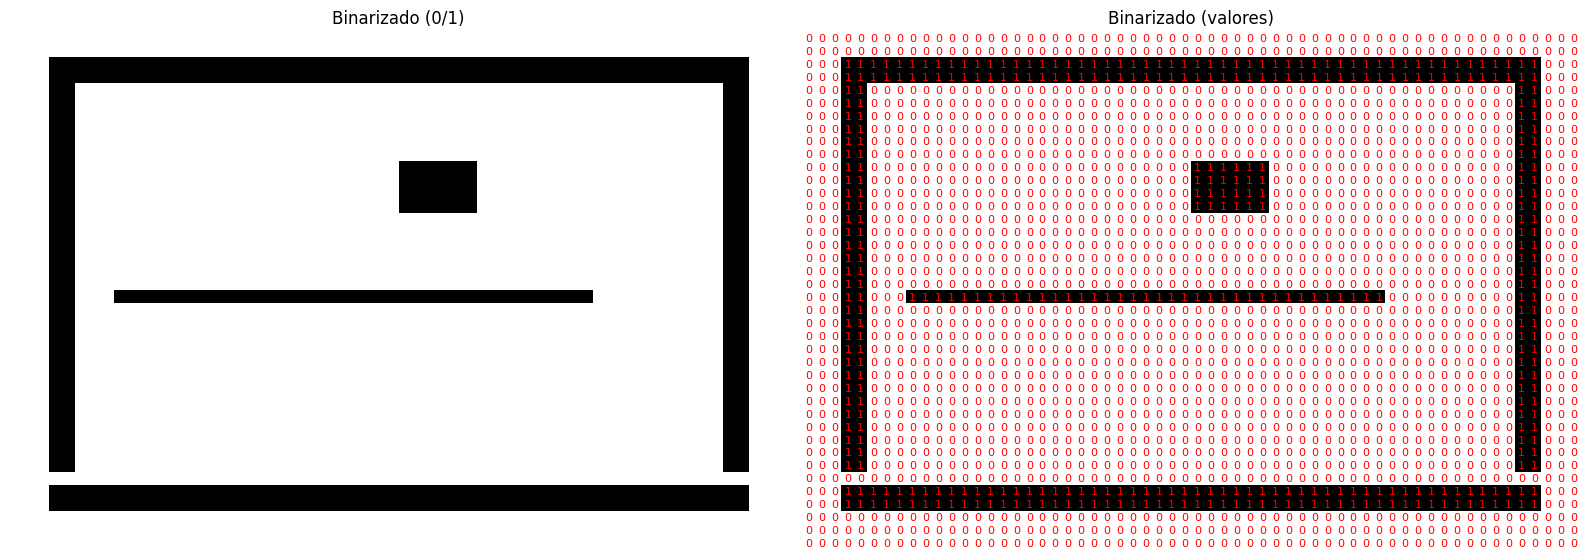

In [14]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1); show_grid_with_values(map_bin, 'Binarizado (0/1)', cmap='gray_r', annotate=False)
plt.subplot(1,2,2); show_grid_with_values(map_bin, 'Binarizado (valores)', cmap='gray_r', annotate=True, fontsize=8)
plt.tight_layout(); plt.show()

## 3) Downsampling: continuo (0..1) y re-binarización
Comparamos factores [2, 4, 8, 16] y umbrales [0.50, 0.25, 0.10].

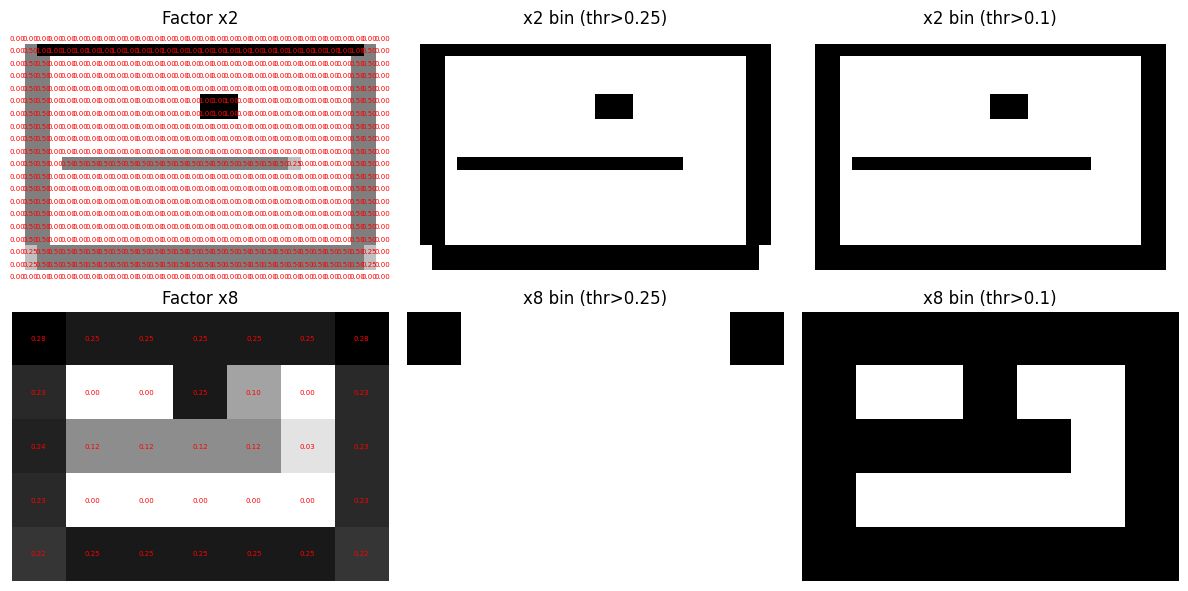

In [ ]:
factors = [2, 8]
thresholds = [0.25, 0.10]
rows = len(factors); cols = 1 + len(thresholds)
plt.figure(figsize=(6*cols, 6*rows))
for r, fac in enumerate(factors):
    cont = downsample_area(map_bin, fac)
    plt.subplot(rows, cols, r*cols + 1)
    show_grid_with_values(cont, title=f'Factor x{fac}', cmap='gray_r', annotate=True, fontsize=5)
    for c, thr in enumerate(thresholds, start=2):
        binr = rebinarize(cont, thr)
        plt.subplot(rows, cols, r*cols + c)
        show_grid_with_values(binr, title=f'x{fac} bin (thr>{thr})', cmap='gray_r', annotate=False)
plt.tight_layout(); plt.show()

## 4) Zoom de un bloque → una celda reducida
Elegimos una celda en el mapa reducido y mostramos el bloque original que la genera.

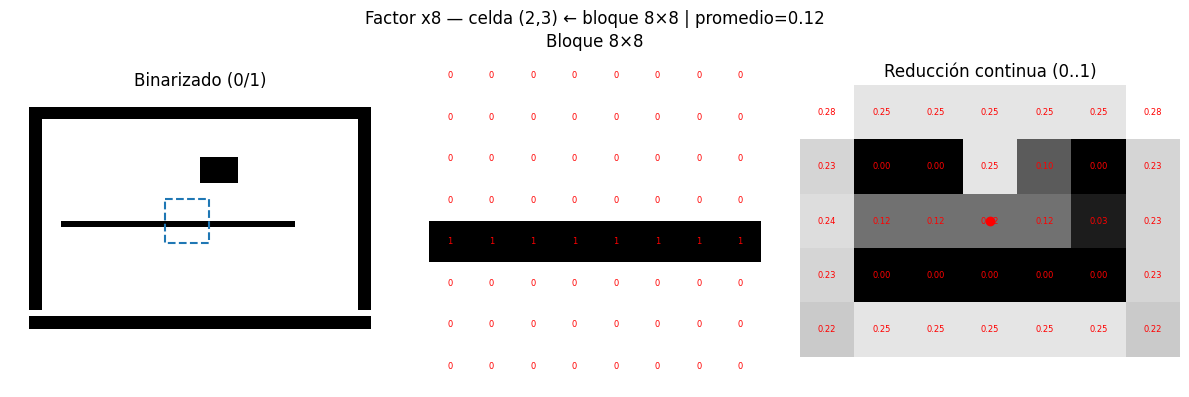

In [5]:
factor = 8  # cambia y re-ejecuta esta celda
cont = downsample_area(map_bin, factor)
h, w = map_bin.shape
new_h, new_w = cont.shape
cy, cx = new_h//2, new_w//2  # celda reducida de interés
ys, xs = cy*factor, cx*factor
block = map_bin[ys:ys+factor, xs:xs+factor]
avg_val = block.mean()
fig, axs = plt.subplots(1,3, figsize=(12,4))
plt.suptitle(f'Factor x{factor} — celda ({cy},{cx}) ← bloque {factor}×{factor} | promedio={avg_val:.2f}')
plt.sca(axs[0]); show_grid_with_values(map_bin, 'Binarizado (0/1)', cmap='gray_r', annotate=False)
rect_y = [ys, ys, ys+factor-1, ys+factor-1, ys]
rect_x = [xs, xs+factor-1, xs+factor-1, xs, xs]
plt.plot(rect_x, rect_y, linestyle='--')
plt.sca(axs[1]); show_grid_with_values(block, f'Bloque {factor}×{factor}', cmap='gray_r', annotate=True, fontsize=6)
plt.sca(axs[2]); show_grid_with_values(cont, 'Reducción continua (0..1)', cmap='gray', annotate=True, fontsize=6)
plt.scatter([cx],[cy], c='red'); plt.tight_layout(); plt.show()

## 5) Re-binarización de la celda elegida con distintos umbrales

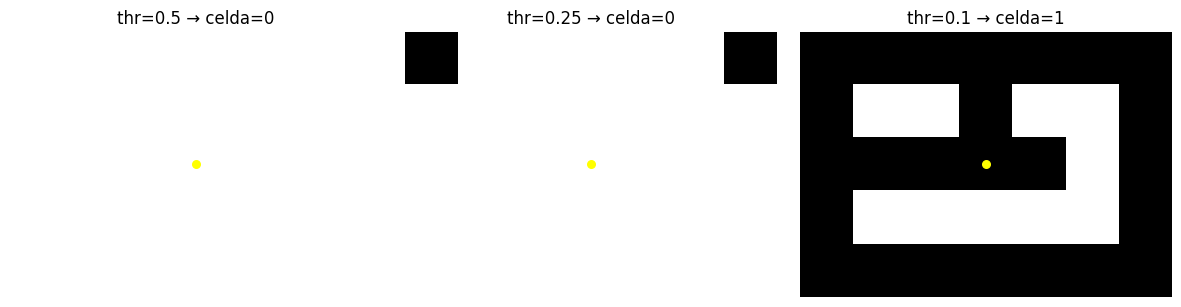

In [6]:
thr_list = [0.50, 0.25, 0.10]
fig, axs = plt.subplots(1, len(thr_list), figsize=(12,3))
for i, thr in enumerate(thr_list):
    binr = rebinarize(cont, thr)
    axs[i].imshow(binr, cmap='gray_r'); axs[i].axis('off')
    axs[i].scatter([cx],[cy], c='yellow', s=30)
    axs[i].set_title(f'thr={thr} → celda={int(binr[cy,cx])}')
plt.tight_layout(); plt.show()